In [3]:
# ============================================================
#  IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# ============================================================
# 6.2 LOAD FEATURE-ENGINEERED DATA
# ============================================================

import pandas as pd
import numpy as np
import json

# Load feature-engineered dataset
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

# Load feature configuration
with open(
    "../data/processed/feature_config.json",
    "r"
) as file:
    feature_config = json.load(file)

# Extract feature definitions
base_features = feature_config["base_features"]
categorical_features = feature_config["categorical_features"]
numerical_features = feature_config["numerical_features"]
boolean_features = feature_config["boolean_features"]
target_variables = feature_config["target_variables"]

print("Dataset Shape:", df.shape)
print("Number of Features:", len(base_features))
print("Target Variables:", target_variables)

Dataset Shape: (10000, 45)
Number of Features: 29
Target Variables: ['CTR', 'conversion_rate', 'ROAS', 'profit']


In [5]:
# ============================================================
# 6.3 FEATURES AND TARGET
# ============================================================

X = df[base_features].copy()
y = df["CTR"].copy()

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 29)
Target Shape: (10000,)


In [6]:
# ============================================================
# 6.4 TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

Training samples: 8000
Testing samples : 2000

Training feature shape: (8000, 29)
Testing feature shape : (2000, 29)


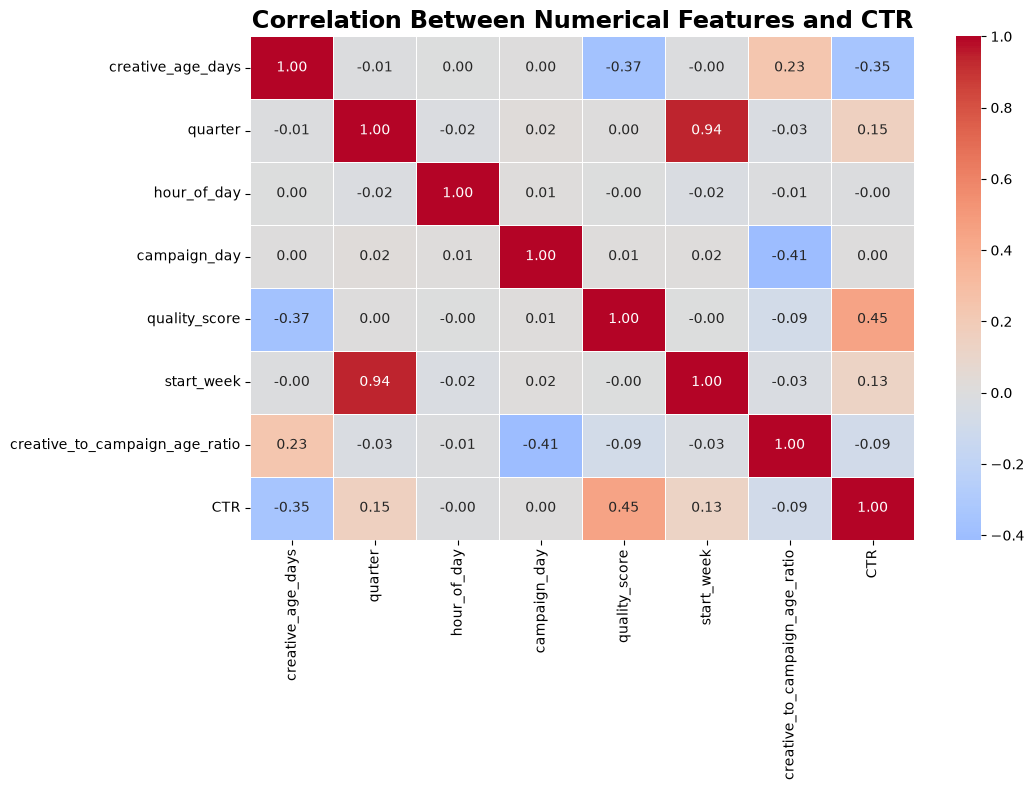

In [17]:
# ============================================================
# 6.5 CORRELATION ANALYSIS
# ============================================================

numeric_features_for_analysis = [
    "creative_age_days",
    "quarter",
    "hour_of_day",
    "campaign_day",
    "quality_score",
    "start_week",
    "creative_to_campaign_age_ratio",
    "CTR"
]

correlation_matrix = (
    df[numeric_features_for_analysis]
    .corr()
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Between Numerical Features and CTR",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 6.6 MULTICOLLINEARITY CHECK — VIF
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    "creative_age_days",
    "quarter",
    "hour_of_day",
    "campaign_day",
    "quality_score",
    "start_week",
    "creative_to_campaign_age_ratio"
]

X_vif = df[vif_features].copy()

vif_results = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_results = (
    vif_results
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_results.round(2))

,Feature,VIF
0,start_week,8.96
1,quarter,8.96
2,creative_to_campaign_age_ratio,1.29
3,creative_age_days,1.23
4,campaign_day,1.22
5,quality_score,1.16
6,hour_of_day,1.00


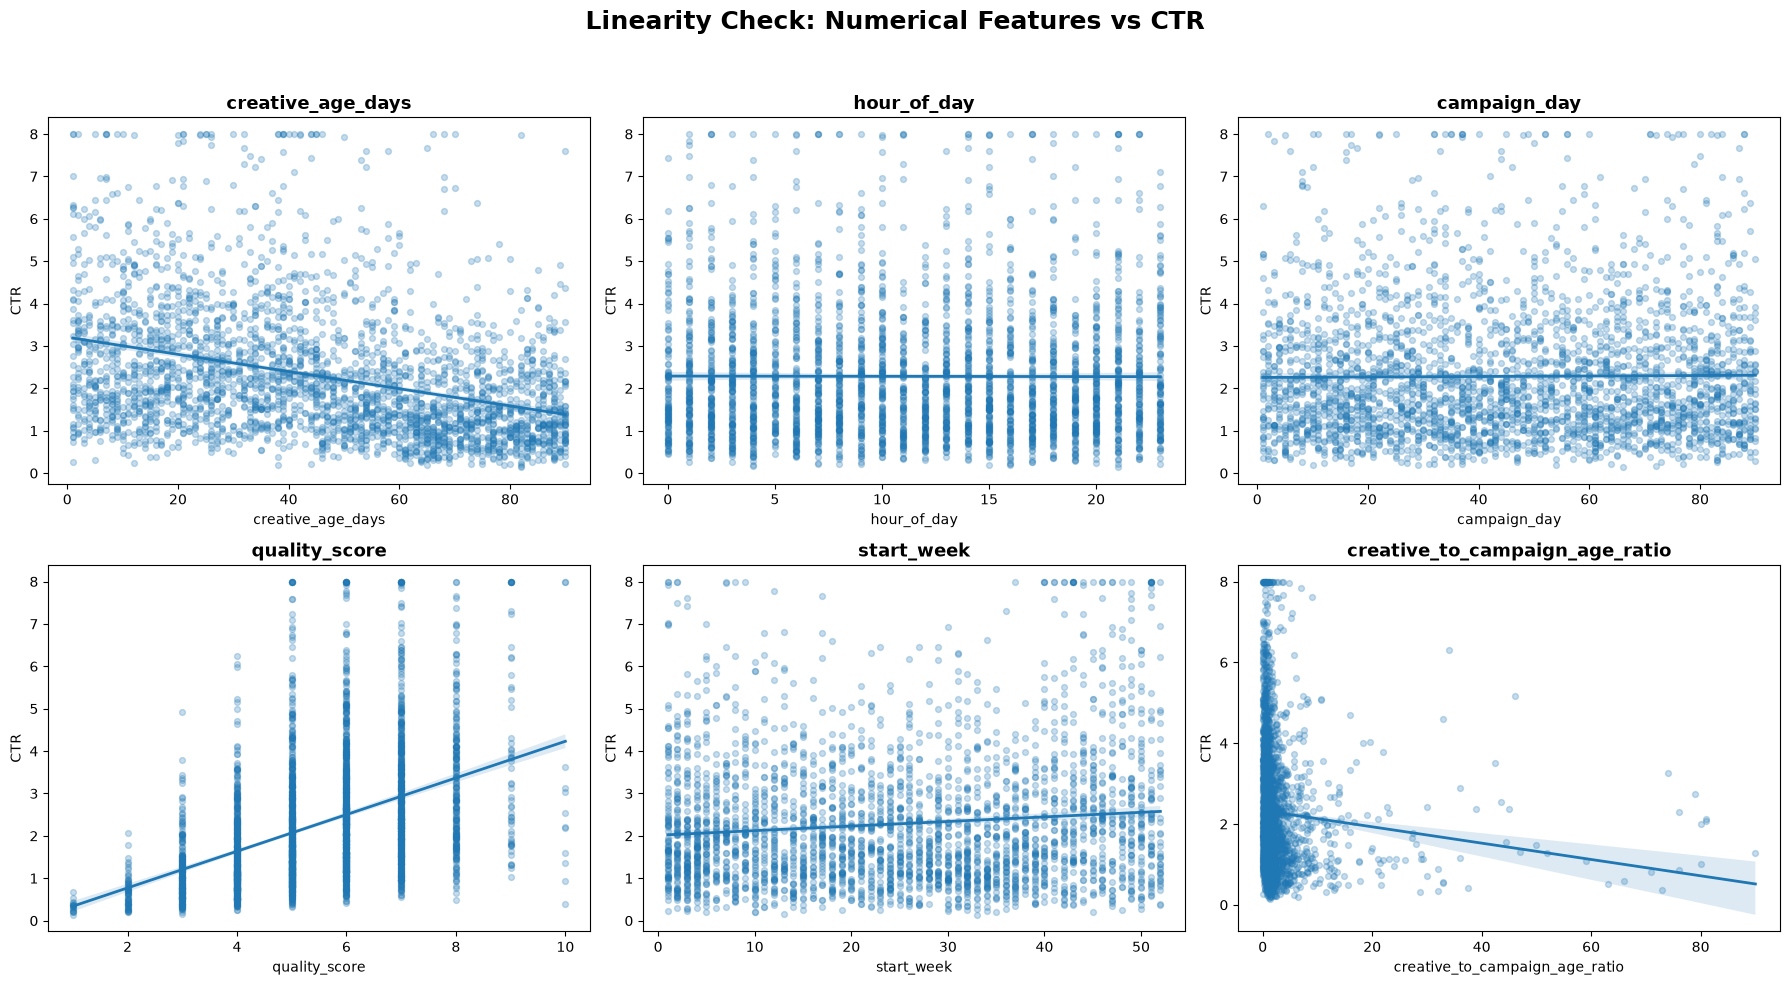

In [19]:
# ============================================================
# 6.7 LINEARITY CHECK
# ============================================================

linearity_features = [
    "creative_age_days",
    "hour_of_day",
    "campaign_day",
    "quality_score",
    "start_week",
    "creative_to_campaign_age_ratio"
]

sample_df = df.sample(
    min(3000, len(df)),
    random_state=42
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

fig.suptitle(
    "Linearity Check: Numerical Features vs CTR",
    fontsize=18,
    fontweight="bold"
)

for ax, feature in zip(
    axes.flat,
    linearity_features
):

    sns.regplot(
        data=sample_df,
        x=feature,
        y="CTR",
        scatter_kws={
            "alpha": 0.25,
            "s": 18
        },
        line_kws={
            "linewidth": 2
        },
        ax=ax
    )

    ax.set_title(
        feature,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("CTR")

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

In [20]:
# ============================================================
# 6.8 HETEROSKEDASTICITY CHECK
# ============================================================

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Numerical predictors
X_hetero = df[vif_features].copy()

# Add intercept
X_hetero = sm.add_constant(X_hetero)

# Fit OLS
ols_model = sm.OLS(
    y,
    X_hetero
).fit()

# Residuals and fitted values
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

# Breusch-Pagan test
bp_test = het_breuschpagan(
    residuals,
    X_hetero
)

bp_results = pd.DataFrame({
    "Test": [
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ],
    "Value": [
        bp_test[0],
        bp_test[1],
        bp_test[2],
        bp_test[3]
    ]
})

display(bp_results.round(4))

,Test,Value
0,LM Statistic,715.5205
1,LM p-value,0.0000
2,F Statistic,110.0066
3,F p-value,0.0000


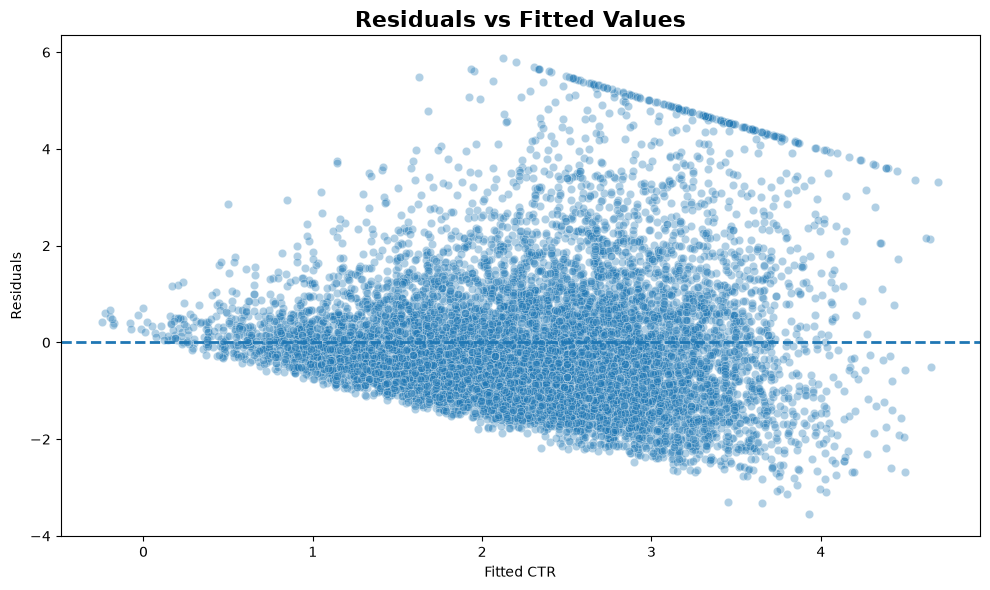

In [21]:
# ============================================================
# RESIDUALS VS FITTED VALUES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=fitted_values,
    y=residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residuals vs Fitted Values",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fitted CTR")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 6.9 CTR FEATURE REFINEMENT
# ============================================================

ctr_features = base_features.copy()

# Remove redundant feature identified through VIF/correlation
if "start_week" in ctr_features:
    ctr_features.remove("start_week")

print("=" * 55)
print("CTR FEATURE REFINEMENT")
print("=" * 55)

print("Original features :", len(base_features))
print("CTR model features:", len(ctr_features))

print("\nRemoved feature:")
print("✓ start_week")

print("\nFinal CTR feature list:")
for feature in ctr_features:
    print("-", feature)

CTR FEATURE REFINEMENT
Original features : 29
CTR model features: 28

Removed feature:
✓ start_week

Final CTR feature list:
- campaign_objective
- platform
- ad_placement
- device_type
- operating_system
- creative_format
- creative_size
- ad_copy_length
- has_call_to_action
- creative_emotion
- creative_age_days
- target_audience_age
- target_audience_gender
- audience_interest_category
- income_bracket
- purchase_intent_score
- retargeting_flag
- quarter
- day_of_week
- hour_of_day
- campaign_day
- quality_score
- industry_vertical
- budget_tier
- start_year
- start_month
- start_day
- creative_to_campaign_age_ratio


start_week will not be used by the CTR model because quarter already provides highly overlapping information.

In [23]:
# ============================================================
# 6.10 PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ctr_categorical_features = [
    feature for feature in categorical_features
    if feature in ctr_features
]

ctr_numerical_features = [
    feature for feature in numerical_features
    if feature in ctr_features
]

ctr_boolean_features = [
    feature for feature in boolean_features
    if feature in ctr_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            ctr_categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            ctr_numerical_features
        ),
        (
            "boolean",
            "passthrough",
            ctr_boolean_features
        )
    ],
    remainder="drop"
)

print("=" * 55)
print("CTR PREPROCESSING PIPELINE")
print("=" * 55)

print("Categorical features:", len(ctr_categorical_features))
print("Numerical features  :", len(ctr_numerical_features))
print("Boolean features    :", len(ctr_boolean_features))
print("Total model features:", len(ctr_features))

CTR PREPROCESSING PIPELINE
Categorical features: 17
Numerical features  : 6
Boolean features    : 2
Total model features: 28


In [24]:
# ============================================================
# 6.11 CANDIDATE MODELS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Candidate models:")

for name in models:
    print("✓", name)

Candidate models:
✓ Linear Regression
✓ Random Forest
✓ Gradient Boosting


In [25]:
# ============================================================
# 6.12 MODEL TRAINING AND COMPARISON
# ============================================================

# Create refined target and features
X = df[ctr_features].copy()
y = df["CTR"].copy()

# Train-test split using refined features
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    trained_models[name] = pipeline

model_results = (
    pd.DataFrame(results)
    .sort_values(
        "R²",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_results.round(4)
)

,Model,MAE,RMSE,R²
0,Gradient Boosting,0.5265,0.7633,0.7628
1,Random Forest,0.6702,0.9367,0.6427
2,Linear Regression,0.7701,1.0677,0.5359


In [27]:
# ============================================================
# 6.13 BEST CTR MODEL
# ============================================================

best_model_name = model_results.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_results = model_results.iloc[0]

print("=" * 55)
print("BEST CTR MODEL")
print("=" * 55)

print("Model:", best_model_name)
print(f"MAE  : {best_results['MAE']:.4f}")
print(f"RMSE : {best_results['RMSE']:.4f}")
print(f"R²   : {best_results['R²']:.4f}")

BEST CTR MODEL
Model: Gradient Boosting
MAE  : 0.5265
RMSE : 0.7633
R²   : 0.7628


In [28]:
# ============================================================
# 6.14 GRADIENT BOOSTING — HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting pipeline
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

# Hyperparameter search space
param_distributions = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

print("=" * 60)
print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("=" * 60)

print("Search combinations:", 
      np.prod([len(v) for v in param_distributions.values()]))

GRADIENT BOOSTING HYPERPARAMETER TUNING
Search combinations: 6400


In [29]:
# ============================================================
# RANDOMIZED SEARCH
# ============================================================

random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("\nHyperparameter tuning completed.")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Hyperparameter tuning completed.


In [30]:
# ============================================================
# 6.15 BEST HYPERPARAMETERS
# ============================================================

print("=" * 60)
print("BEST GRADIENT BOOSTING PARAMETERS")
print("=" * 60)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest Cross-Validation R²: "
    f"{random_search.best_score_:.4f}"
)

BEST GRADIENT BOOSTING PARAMETERS
model__subsample: 0.9
model__n_estimators: 500
model__min_samples_split: 20
model__min_samples_leaf: 10
model__max_depth: 5
model__learning_rate: 0.03

Best Cross-Validation R²: 0.7876


In [36]:
# ============================================================
# 6.16 TUNED MODEL TEST PERFORMANCE
# ============================================================

tuned_model = random_search.best_estimator_

# Predictions
y_pred_tuned = tuned_model.predict(X_test)

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)

# MAPE
# Exclude zero actual values to avoid division by zero
non_zero_mask = y_test != 0

tuned_mape = (
    np.mean(
        np.abs(
            (y_test[non_zero_mask] - y_pred_tuned[non_zero_mask])
            / y_test[non_zero_mask]
        )
    ) * 100
)

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

tuned_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²"
    ],

    "Tuned Gradient Boosting": [
        tuned_mae,
        tuned_rmse,
        tuned_mape,
        tuned_r2
    ]
})

display(
    tuned_results.round(4)
)

,Metric,Tuned Gradient Boosting
0,MAE,0.4794
1,RMSE,0.7058
2,MAPE (%),24.6955
3,R²,0.7972


In [37]:
# ============================================================
# 6.17 BEFORE VS AFTER HYPERPARAMETER TUNING
# ============================================================

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],

    "Before Tuning": [
        0.5265,
        0.7633,
        0.7628
    ],

    "After Tuning": [
        tuned_mae,
        tuned_rmse,
        tuned_r2
    ]
})

display(
    comparison.round(4)
)

,Metric,Before Tuning,After Tuning
0,MAE,0.5265,0.4794
1,RMSE,0.7633,0.7058
2,R²,0.7628,0.7972


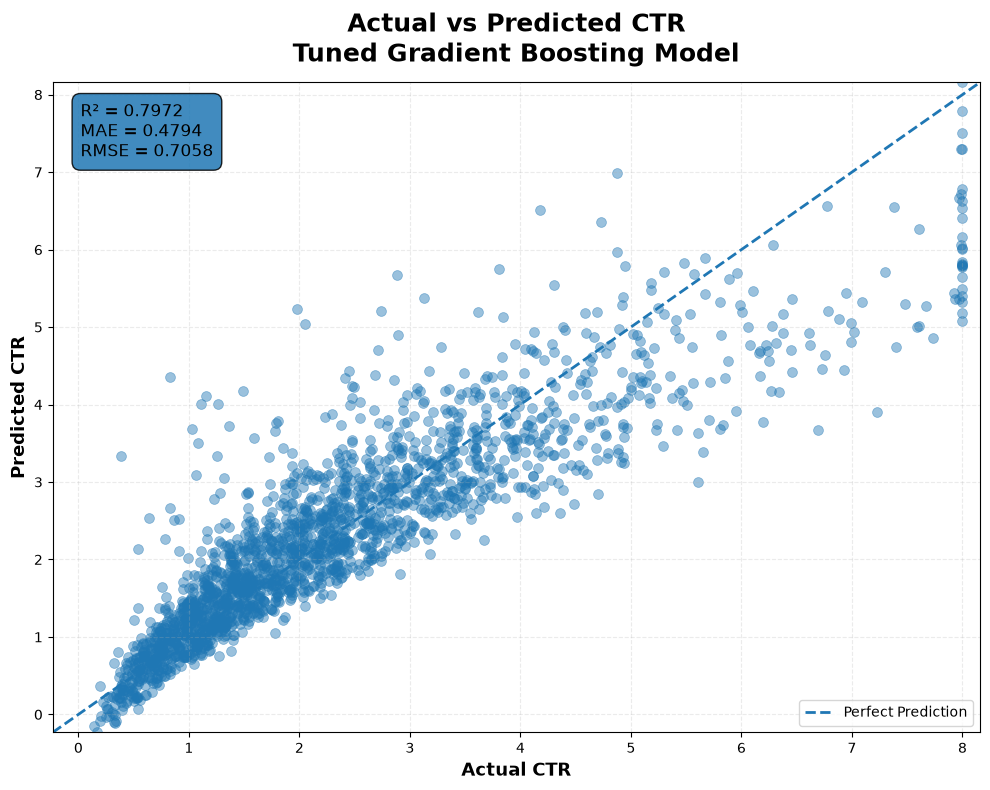

In [38]:
# ============================================================
# 6.17 ACTUAL VS PREDICTED CTR
# ============================================================

# Generate predictions using tuned model
y_pred = tuned_model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# ------------------------------------------------------------
# Create visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.45,
    s=50,
    edgecolor=None,
    ax=ax
)

# ------------------------------------------------------------
# Perfect prediction reference line
# ------------------------------------------------------------

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

# ------------------------------------------------------------
# Labels and title
# ------------------------------------------------------------

ax.set_title(
    "Actual vs Predicted CTR\n"
    "Tuned Gradient Boosting Model",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Actual CTR",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Predicted CTR",
    fontsize=13,
    fontweight="bold"
)

# ------------------------------------------------------------
# Display model metrics
# ------------------------------------------------------------

metrics_text = (
    f"R² = {r2:.4f}\n"
    f"MAE = {mae:.4f}\n"
    f"RMSE = {rmse:.4f}"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.85
    )
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.legend(
    loc="lower right",
    frameon=True
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

# Keep both axes comparable
ax.set_xlim(min_value, max_value)
ax.set_ylim(min_value, max_value)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 6.18 RESIDUAL ANALYSIS
# ============================================================

# Calculate residuals
residuals = y_test - y_pred

# Create residual dataframe
residual_df = pd.DataFrame({
    "Actual_CTR": y_test,
    "Predicted_CTR": y_pred,
    "Residual": residuals
})

display(residual_df.head().round(4))

,Actual_CTR,Predicted_CTR,Residual
6252,0.841,0.9525,-0.1115
4684,0.354,0.3041,0.0499
1731,1.973,1.6703,0.3027
4742,4.043,3.3890,0.6540
4521,1.785,2.0683,-0.2833


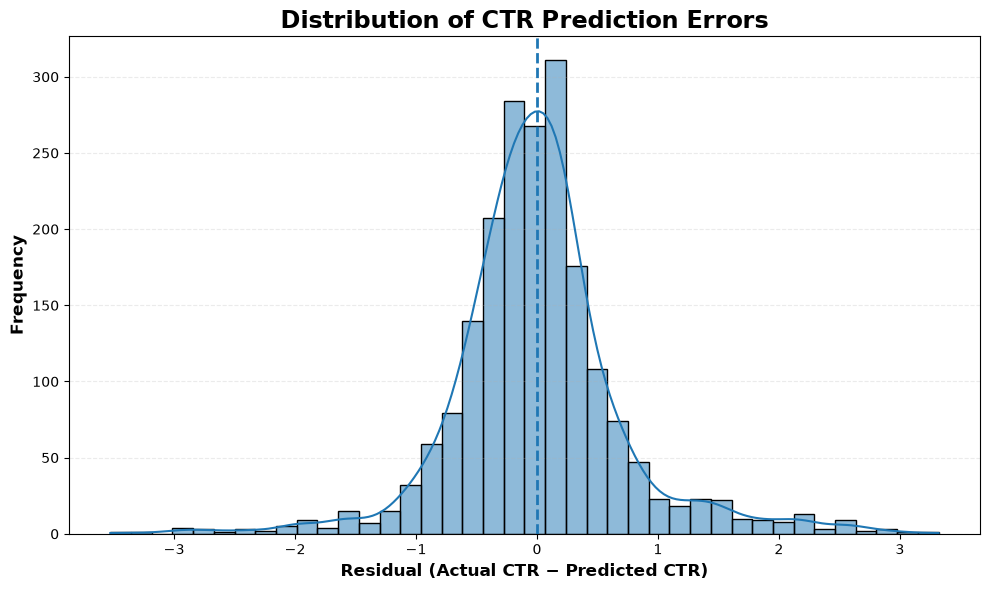

In [39]:
# ============================================================
# 6.18.1 RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Distribution of CTR Prediction Errors",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Residual (Actual CTR − Predicted CTR)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Frequency",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

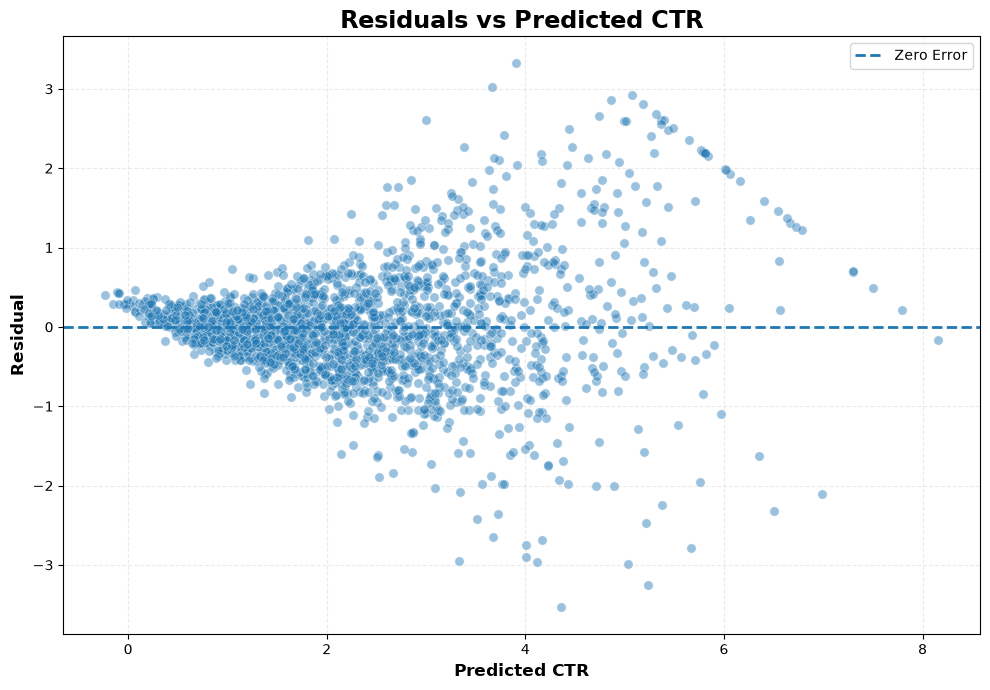

In [40]:
# ============================================================
# 6.18.2 RESIDUALS VS PREDICTED CTR
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.45,
    s=45
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.title(
    "Residuals vs Predicted CTR",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Predicted CTR",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Residual",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.grid(
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Residual Analysis

The residual distribution is centered close to zero, indicating that the tuned Gradient Boosting model does not exhibit a strong overall systematic bias.

However, the residuals vs. predicted CTR plot shows that the spread of errors increases for higher predicted CTR values. This indicates that the model has greater prediction uncertainty for campaigns with higher CTR values.

A small number of larger positive and negative residuals are also visible, which is consistent with the presence of extreme CTR observations identified during exploratory analysis.

Overall, the residual analysis indicates that the tuned model provides a good fit, although prediction errors are not completely uniform across all CTR levels.

In [41]:
# ============================================================
# 6.19 FINAL CTR MODEL SUMMARY
# ============================================================

final_ctr_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Number of Features",
        "Test Samples",
        "MAE",
        "RMSE",
        "R²"
    ],

    "Value": [
        "Tuned Gradient Boosting",
        len(ctr_features),
        len(X_test),
        round(mae, 4),
        round(rmse, 4),
        round(r2, 4)
    ]
})

display(final_ctr_summary)

,Metric,Value
0,Model,Tuned Gradient Boosting
1,Number of Features,28
2,Test Samples,2000
3,MAE,0.4794
4,RMSE,0.7058
5,R²,0.7972


In [42]:
# ============================================================
# 6.20 SAVE FINAL CTR MODEL
# ============================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

final_model_path = "../models/ctr_best_model.pkl"

joblib.dump(
    tuned_model,
    final_model_path
)

print("Final CTR model saved successfully.")
print("Path:", final_model_path)

Final CTR model saved successfully.
Path: ../models/ctr_best_model.pkl


In [43]:
# ============================================================
# 6.21 FEATURE IMPORTANCE ANALYSIS
# ============================================================

# Extract the fitted preprocessing pipeline
fitted_preprocessor = tuned_model.named_steps["preprocessor"]

# Extract the trained Gradient Boosting model
gb_model = tuned_model.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance
importance_values = gb_model.feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort by importance
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(
    feature_importance.head(15).round(4)
)

,Feature,Importance
0,numerical__quality_score,0.2039
1,categorical__creative_format_Video,0.1192
2,numerical__creative_age_days,0.1019
3,categorical__industry_vertical_E-commerce,0.0975
4,numerical__quarter,0.0971
5,categorical__device_type_Desktop,0.0420
6,categorical__target_audience_age_18-24,0.0379
7,categorical__day_of_week_Saturday,0.0314
8,categorical__day_of_week_Sunday,0.0303
9,categorical__creative_format_Text,0.0259


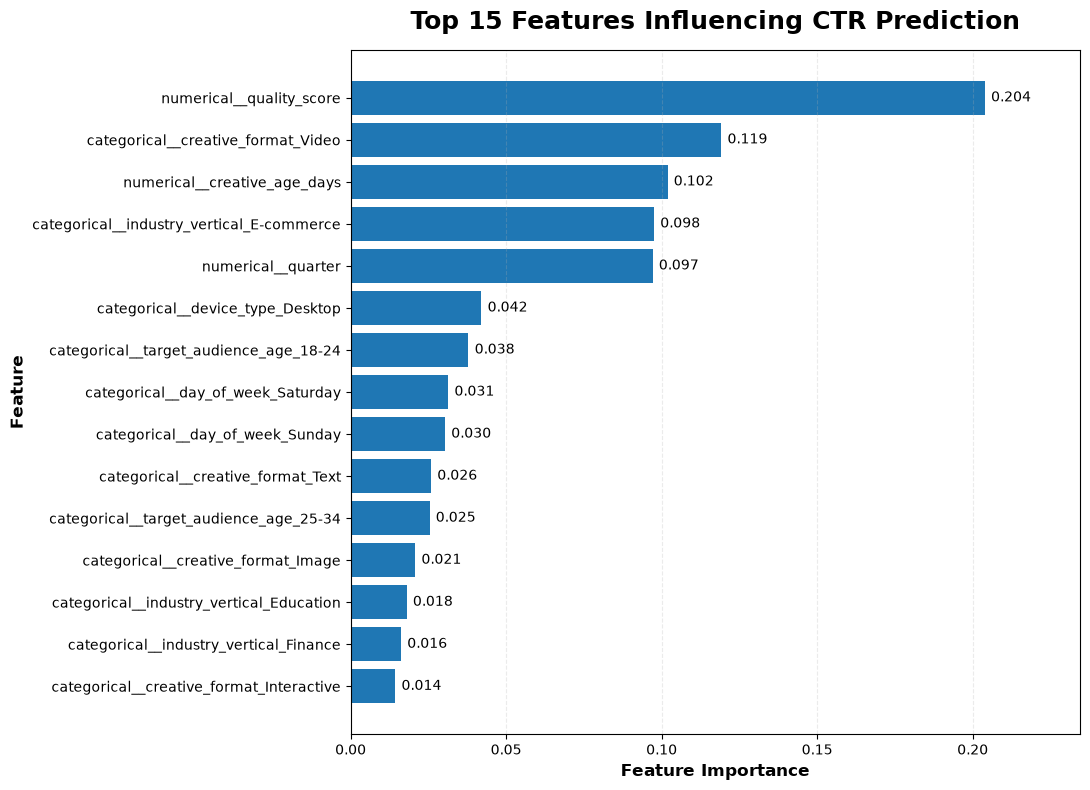

In [44]:
# ============================================================
# 6.21.1 TOP 15 FEATURE IMPORTANCE
# ============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

# Add exact importance values
for bar, value in zip(
    bars,
    top_features["Importance"]
):
    plt.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Features Influencing CTR Prediction",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Feature Importance",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Feature",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# Leave space for value labels
plt.xlim(
    0,
    top_features["Importance"].max() * 1.15
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# 6.21.2 SAVE FEATURE IMPORTANCE
# ============================================================

import os

os.makedirs("../outputs", exist_ok=True)

feature_importance.to_csv(
    "../outputs/ctr_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")
print("Path: ../outputs/ctr_feature_importance.csv")

Feature importance saved successfully.
Path: ../outputs/ctr_feature_importance.csv
